# MLflow & database

Тестирование подключения к MLFLow и БД из Jupyter Notebook

## Configuration

In [1]:
# Хак, чтобы добавить корень проекта в path для импорта модулей
import sys
from pathlib import Path

def find_repo_root() -> Path:
    path = Path.cwd().resolve()
    for candidate in [path, *path.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Could not find repo root (pyproject.toml). Open this notebook from the repo.")

sys.path.append(str(find_repo_root()))
sys.path

['C:\\Users\\baben_bakg1j1\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\python312.zip',
 'C:\\Users\\baben_bakg1j1\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\DLLs',
 'C:\\Users\\baben_bakg1j1\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\Lib',
 'C:\\Users\\baben_bakg1j1\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none',
 'c:\\Users\\baben_bakg1j1\\HSE\\annual_project\\stocks-advisor\\.venv',
 '',
 'c:\\Users\\baben_bakg1j1\\HSE\\annual_project\\stocks-advisor\\.venv\\Lib\\site-packages',
 'c:\\Users\\baben_bakg1j1\\HSE\\annual_project\\stocks-advisor\\.venv\\Lib\\site-packages\\win32',
 'c:\\Users\\baben_bakg1j1\\HSE\\annual_project\\stocks-advisor\\.venv\\Lib\\site-packages\\win32\\lib',
 'c:\\Users\\baben_bakg1j1\\HSE\\annual_project\\stocks-advisor\\.venv\\Lib\\site-packages\\Pythonwin',
 'C:\\Users\\baben_bakg1j1\\HSE\\annual_project\\stocks-advisor']

In [2]:
import pandas as pd
import numpy as np
from app.core.processors.feature_generator import FeatureGenerator
from app.core.database import NewsArticleRepository, get_db_session, AssetCandleRepository
from datetime import UTC, datetime
import mlflow
from jupyter_utils import setup_jupyter_notebook

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
from torch.utils.data import DataLoader
from torch import nn, optim

from dataset import StockDataset
from model import StockLSTMRegressor
from train import train, calculate_metrics

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Код для загрузки конфига и подключения к MLFlow
# Для работы с продом в корне проекта должен быть .env файл с всеми нужными переменными окружения
# Для локальной разработки .env не нужен

# Подключение к проду
setup_jupyter_notebook(environment='prod', experiment='test')

# Подключение к локальным БД и MLFlow
# setup_jupyter_notebook(environment='local', experiment='test')

Environment: prod
APP_CONFIG: config.toml
Tracking URI: http://localhost:5050
S3 endpoint: http://localhost:9050
Experiment: test
Database: localhost:15432/stocks_advisor_db


## MLFlow

Пример логгирования эксперимента в MLFlow

In [30]:
run_name = f"smoke-test-{datetime.now(UTC).strftime('%Y%m%d-%H%M%S')}"

with mlflow.start_run(run_name=run_name) as run:
    mlflow.log_param("source", "mlflow_smoke_test")
    mlflow.log_metric("ping", 1.0)
    mlflow.log_dict({"status": "ok"}, "smoke.json")

print(f"Run ID: {run.info.run_id}")
print(f"Run name: {run_name}")
print("Smoke test passed.")

🏃 View run smoke-test-20260601-091700 at: http://localhost:5050/#/experiments/3/runs/139fac4fa8af4c69b234951199c3bba7
🧪 View experiment at: http://localhost:5050/#/experiments/3
Run ID: 139fac4fa8af4c69b234951199c3bba7
Run name: smoke-test-20260601-091700
Smoke test passed.


## Загрузка данных

In [6]:
# Загрузка свечей MOEX

async with get_db_session() as session:
    repo = AssetCandleRepository(session)
    candles_by_ticker = await repo.get_dataframe_by_ticker()

print(f'{len(candles_by_ticker)} tickers')
for ticker, df in candles_by_ticker.items():
    print(f'  {ticker}: {len(df)} rows')

17 tickers
  BRENT: 15612 rows
  CNYRUBF: 15577 rows
  EURRUBF: 14947 rows
  GAZP: 17154 rows
  GLDRUB_TOM: 11560 rows
  GMKN: 14926 rows
  IMOEX: 9623 rows
  LKOH: 17151 rows
  ROSN: 17148 rows
  SBER: 17151 rows
  T: 16535 rows
  TATN: 14965 rows
  TCSG: 9086 rows
  USDRUBF: 15586 rows
  VTBR: 14920 rows
  YDEX: 6725 rows
  YNDX: 7814 rows


In [7]:
# Загрузка данных по новостям

LIMIT = 1000000

async with get_db_session() as session:
    repo = NewsArticleRepository(session)
    enrichments_df = await repo.get_all_enrichments_as_dataframe(limit=LIMIT)
enrichments_df.rename(columns={'published_at':'date'}, inplace=True)
print(f'Enrichments: {len(enrichments_df)} rows')
enrichments_df.head()

Enrichments: 191154 rows


,id,news_article_id,date,topic,tickers,sector,sentiment,sentiment_score
0,192288,16713,2022-05-01,business,[],MOEXOG,negative,0.946310
1,192289,16722,2022-05-01,politics,[],MOEXOG,negative,0.676439
2,192290,16721,2022-05-01,politics,[],MOEXRE,negative,0.909327
3,192291,16720,2022-05-01,politics,[],MOEXIT,negative,0.825744
4,192292,16719,2022-05-01,society,[],MOEXTN,negative,0.955776


## Генерация признаков

In [8]:
# Генерация фич

features_by_ticker = {}
fg = FeatureGenerator()

for ticker, df in candles_by_ticker.items():
    features_by_ticker[ticker] = fg.process(
        df=df,
        include_original=False,
        add_targets=True,
        clean=True,
    ).drop(['target_class'], axis=1)
features_by_ticker['SBER'].head()

,begin,MA_20,MA_50,MA_90,MA_200,EMA_20,EMA_50,EMA_90,EMA_200,WMA_20,...,DISTANCE_MA_200,DISTANCE_EMA_20,DISTANCE_EMA_50,DISTANCE_EMA_90,DISTANCE_EMA_200,DISTANCE_WMA_20,DISTANCE_WMA_50,DISTANCE_WMA_90,DISTANCE_WMA_200,target_price_change
200,2022-06-02 10:00:00,120.6790,121.8344,122.674889,128.20900,120.927026,121.766630,122.704015,124.702217,120.548048,...,-0.068162,-0.012049,-0.018861,-0.026356,-0.041958,-0.008943,-0.015068,-0.022192,-0.034156,-0.912363
201,2022-06-02 12:00:00,120.5965,121.7286,122.625333,128.04905,120.843499,121.699291,122.645023,124.648846,120.488143,...,-0.062469,-0.006566,-0.013552,-0.021159,-0.036894,-0.003636,-0.009715,-0.016981,-0.028829,-1.407747
202,2022-06-02 14:00:00,120.4935,121.6098,122.569667,127.88395,120.687928,121.601642,122.568689,124.586546,120.356095,...,-0.067827,-0.012246,-0.019668,-0.027403,-0.043155,-0.009523,-0.015842,-0.023259,-0.034938,-0.914353
203,2022-06-02 16:00:00,120.3495,121.4710,122.506889,127.70375,120.492887,121.485466,122.481407,124.518533,120.179571,...,-0.070975,-0.015378,-0.023422,-0.031363,-0.047210,-0.012811,-0.019605,-0.027241,-0.038837,-0.362441
204,2022-06-02 18:00:00,120.2385,121.3390,122.442444,127.52625,120.350708,121.387970,122.404080,124.455509,120.051048,...,-0.066859,-0.011223,-0.019672,-0.027810,-0.043835,-0.008755,-0.015842,-0.023672,-0.035243,-0.672269


In [9]:
def merge_tonality_with_prices(ticker, price_data, tonality_data, horizons_hours, sector_to_ticker=None):
    if sector_to_ticker is None:
        sector_to_ticker = {
            'MOEXFN': ['SBER', 'VTBR', 'TCSG'],
            'MOEXOG': ['GAZP', 'LKOH', 'ROSN', 'TATN'],
            'MOEXIT': ['YDEX'],
            'MOEXMM': ['GMKN']
        }

    result = price_data.copy()
    tonality_copy = tonality_data.copy()

    result['begin'] = pd.to_datetime(result['begin'])
    tonality_copy['date'] = pd.to_datetime(tonality_copy['date'])

    def parse_ticker_list(x):
        if x is None:
            return []
        if isinstance(x, (list, tuple, set, np.ndarray, pd.Series)):
            return [str(t).upper().strip() for t in x if str(t).strip()]
        if isinstance(x, str):
            s = x.strip('[]').strip()
            if not s:
                return []
            return [t.upper().strip().strip("'\"") for t in s.split(',') if t.strip()]
        try:
            if pd.isna(x):
                return []
        except Exception:
            pass
        sx = str(x).strip()
        if not sx or sx == '[]':
            return []
        return [t.upper().strip().strip("'\"") for t in sx.split(',') if t.strip()]

    sentiment_map = {'positive': 1, 'neutral': 0, 'negative': -1}

    if 'tickers' in tonality_copy.columns:
        tonality_copy['tickers_list'] = tonality_copy['tickers'].apply(parse_ticker_list)
    else:
        tonality_copy['tickers_list'] = [[] for _ in range(len(tonality_copy))]
    if 'sentiment' in tonality_copy.columns:
        tonality_copy['sentiment_value'] = tonality_copy['sentiment'].map(sentiment_map)
    else:
        tonality_copy['sentiment_value'] = pd.Series([pd.NA] * len(tonality_copy))

    def is_news_for_ticker(row, target_ticker):
        target = target_ticker.upper()
        if target in row['tickers_list']:
            return True
        sector = str(row.get('sector', '')).upper()
        return target in [t.upper() for t in sector_to_ticker.get(sector, [])]

    news_for_ticker = tonality_copy[
        tonality_copy.apply(lambda row: is_news_for_ticker(row, ticker), axis=1)
    ].copy()

    if len(news_for_ticker) == 0:
        for h in horizons_hours:
            col = 'sentiment' if h == 2 else f'sentiment_{h}h'
            result[col] = np.nan
        return result

    for h in horizons_hours:
        col = 'sentiment' if h == 2 else f'sentiment_{h}h'
        result[col] = np.nan

    unique_times = sorted(result['begin'].unique())

    for current_time in unique_times:
        for h in horizons_hours:
            window_start = current_time - pd.Timedelta(hours=h)
            mask_news = (news_for_ticker['date'] > window_start) & (news_for_ticker['date'] <= current_time)
            window_news = news_for_ticker.loc[mask_news, 'sentiment_value'].dropna()
            if len(window_news) > 0:
                col = 'sentiment' if h == 2 else f'sentiment_{h}h'
                result.loc[result['begin'] == current_time, col] = window_news.mean()

    return result

In [10]:
for ticker in ['SBER', 'TCSG', 'GAZP', 'LKOH', 'ROSN']:
    features_by_ticker[ticker] = merge_tonality_with_prices(
        ticker, features_by_ticker[ticker], enrichments_df, horizons_hours=[2, 24, 72, 168])

In [11]:
for ticker in ['SBER', 'TCSG', 'GAZP', 'LKOH', 'ROSN']:
    features_by_ticker[ticker] = features_by_ticker[ticker].fillna(0)

In [12]:
def train_test_split_by_date(df, target_column, test_size=0.2):
    df = df.sort_values('begin').reset_index(drop=True)
    split_idx = int(len(df) * (1 - test_size))
    
    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()
    
    print(f"Train: {train_df['begin'].min()} - {train_df['begin'].max()} ({len(train_df)} samples)")
    print(f"Test:  {test_df['begin'].min()} - {test_df['begin'].max()} ({len(test_df)} samples)")
    
    X_train = train_df.drop(columns=['begin', target_column])
    y_train = train_df[target_column]
    
    X_test = test_df.drop(columns=['begin', target_column])
    y_test = test_df[target_column]
    
    print(f"Признаков: {X_train.shape[1]}")
    
    return X_train, X_test, y_train, y_test

In [13]:
def visualize_predictions_comparison(results_df, title="Сравнение реальных и предсказанных изменений"):
    if results_df['begin'].dtype == 'object':
        results_df = results_df.copy()
        results_df['begin'] = pd.to_datetime(results_df['begin'])
    
    results_df = results_df.sort_values('begin')
    
    plt.figure(figsize=(16, 8))
    
    plt.plot(results_df['begin'], results_df['target_price_change'], 
             linewidth=2, color='#2E8B57', label='Реальное изменение', marker='o', markersize=3, alpha=0.8)
    plt.plot(results_df['begin'], results_df['predict'], 
             linewidth=2, color='#DC143C', label='Предсказанное изменение', marker='s', markersize=3, alpha=0.8)
    
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('Изменение цены (%)', fontsize=12)
    plt.xlabel('Дата', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    
    ax = plt.gca()
    
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [14]:
X_train_SBER, X_test_SBER, y_train_SBER, y_test_SBER = train_test_split_by_date(
    df=features_by_ticker['SBER'], 
    target_column='target_price_change',
    test_size=0.2
)

X_train_TCSG, X_test_TCSG, y_train_TCSG, y_test_TCSG = train_test_split_by_date(
    df=features_by_ticker['TCSG'], 
    target_column='target_price_change',
    test_size=0.2
)

X_train_GAZP, X_test_GAZP, y_train_GAZP, y_test_GAZP = train_test_split_by_date(
    df=features_by_ticker['GAZP'], 
    target_column='target_price_change',
    test_size=0.2
)

X_train_LKOH, X_test_LKOH, y_train_LKOH, y_test_LKOH = train_test_split_by_date(
    df=features_by_ticker['LKOH'], 
    target_column='target_price_change',
    test_size=0.2
)

X_train_ROSN, X_test_ROSN, y_train_ROSN, y_test_ROSN = train_test_split_by_date(
    df=features_by_ticker['ROSN'], 
    target_column='target_price_change',
    test_size=0.2
)

Train: 2022-06-02 10:00:00 - 2025-09-02 18:00:00 (4158 samples)
Test:  2025-09-03 10:00:00 - 2026-05-16 18:00:00 (1040 samples)
Признаков: 87
Train: 2022-07-04 10:00:00 - 2024-06-10 12:00:00 (2282 samples)
Test:  2024-06-10 14:00:00 - 2024-11-20 18:00:00 (571 samples)
Признаков: 87
Train: 2022-06-02 10:00:00 - 2025-09-02 18:00:00 (4158 samples)
Test:  2025-09-03 10:00:00 - 2026-05-16 18:00:00 (1040 samples)
Признаков: 87
Train: 2022-06-02 10:00:00 - 2025-09-02 18:00:00 (4158 samples)
Test:  2025-09-03 10:00:00 - 2026-05-16 18:00:00 (1040 samples)
Признаков: 87
Train: 2022-06-02 10:00:00 - 2025-09-02 18:00:00 (4158 samples)
Test:  2025-09-03 10:00:00 - 2026-05-16 18:00:00 (1040 samples)
Признаков: 87


Сбер

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

SEQUENCE_LENGTH = 9
BATCH_SIZE = 8
HIDDEN_SIZE = 8
NUM_LAYERS = 1
DROPOUT = 0.7
NUM_EPOCHS = 10
LEARNING_RATE = 0.0005
WEIGHT_DECAY = 0.01

Device: cpu


In [16]:
train_dataset = StockDataset(X_train_SBER, y_train_SBER, sequence_length=SEQUENCE_LENGTH)
test_dataset = StockDataset(X_test_SBER, y_test_SBER, sequence_length=SEQUENCE_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Создано 4150 последовательностей длины 9
Количество признаков: 87
Создано 1032 последовательностей длины 9
Количество признаков: 87


In [17]:
model = StockLSTMRegressor(
    input_size=train_dataset.num_features,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Всего параметров: {total_params:,}")

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = None

Всего параметров: 3,113


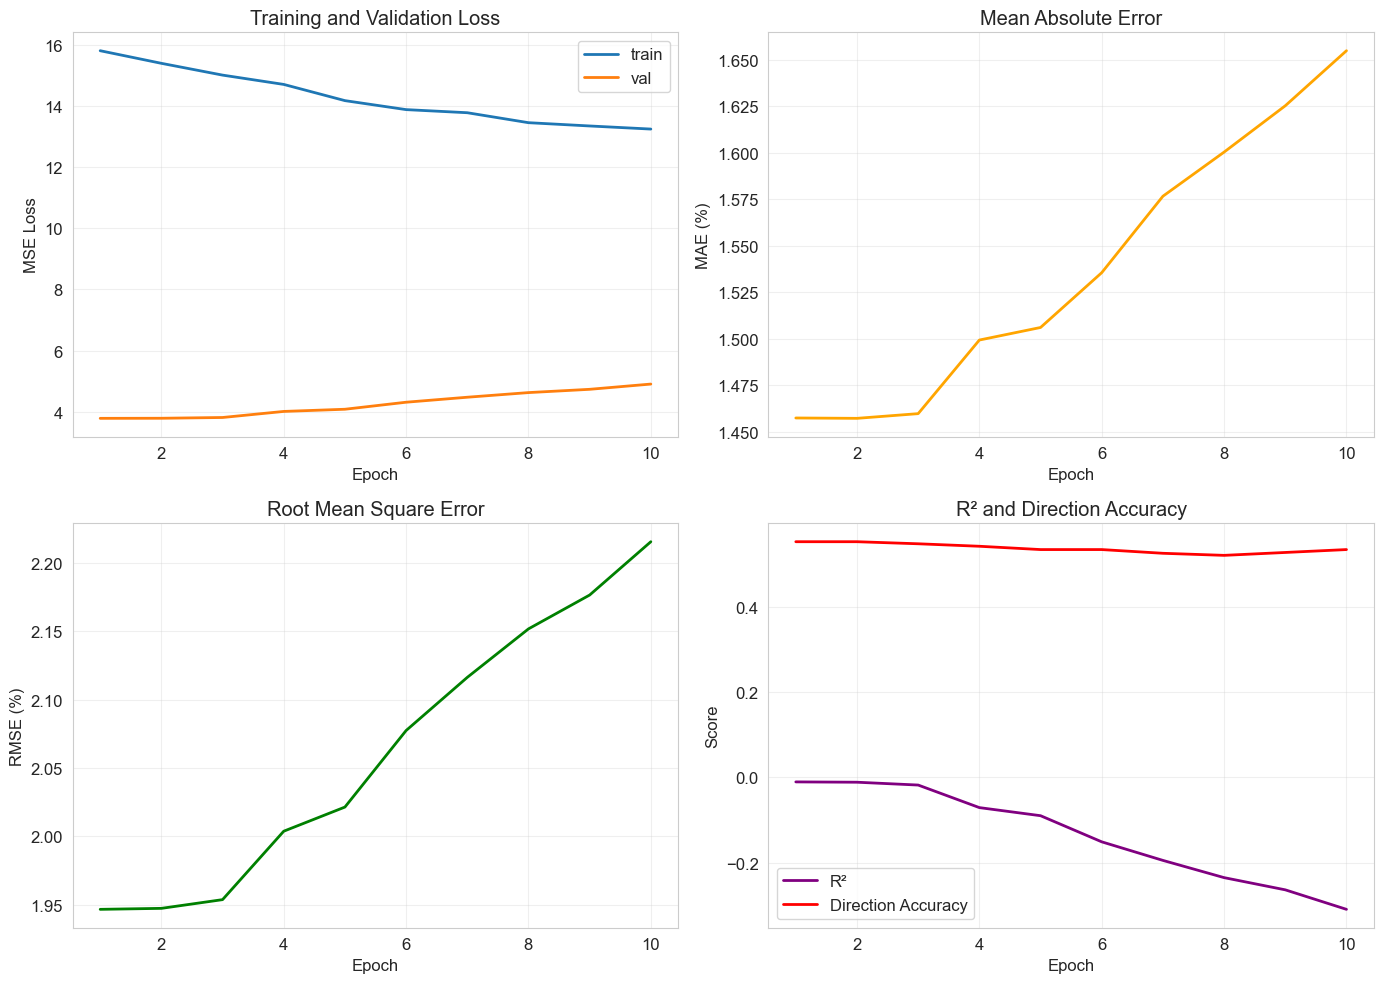


Epoch 10/10:
  Train Loss: 13.240486
  Val Loss:   4.908554
  MAE:  1.6549%
  RMSE: 2.2155%
  R²:   -0.3094
  Dir Acc: 0.5339


In [18]:
train_losses, val_losses, val_metrics = train(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    train_loader=train_loader,
    val_loader=test_loader,
    num_epochs=NUM_EPOCHS
)

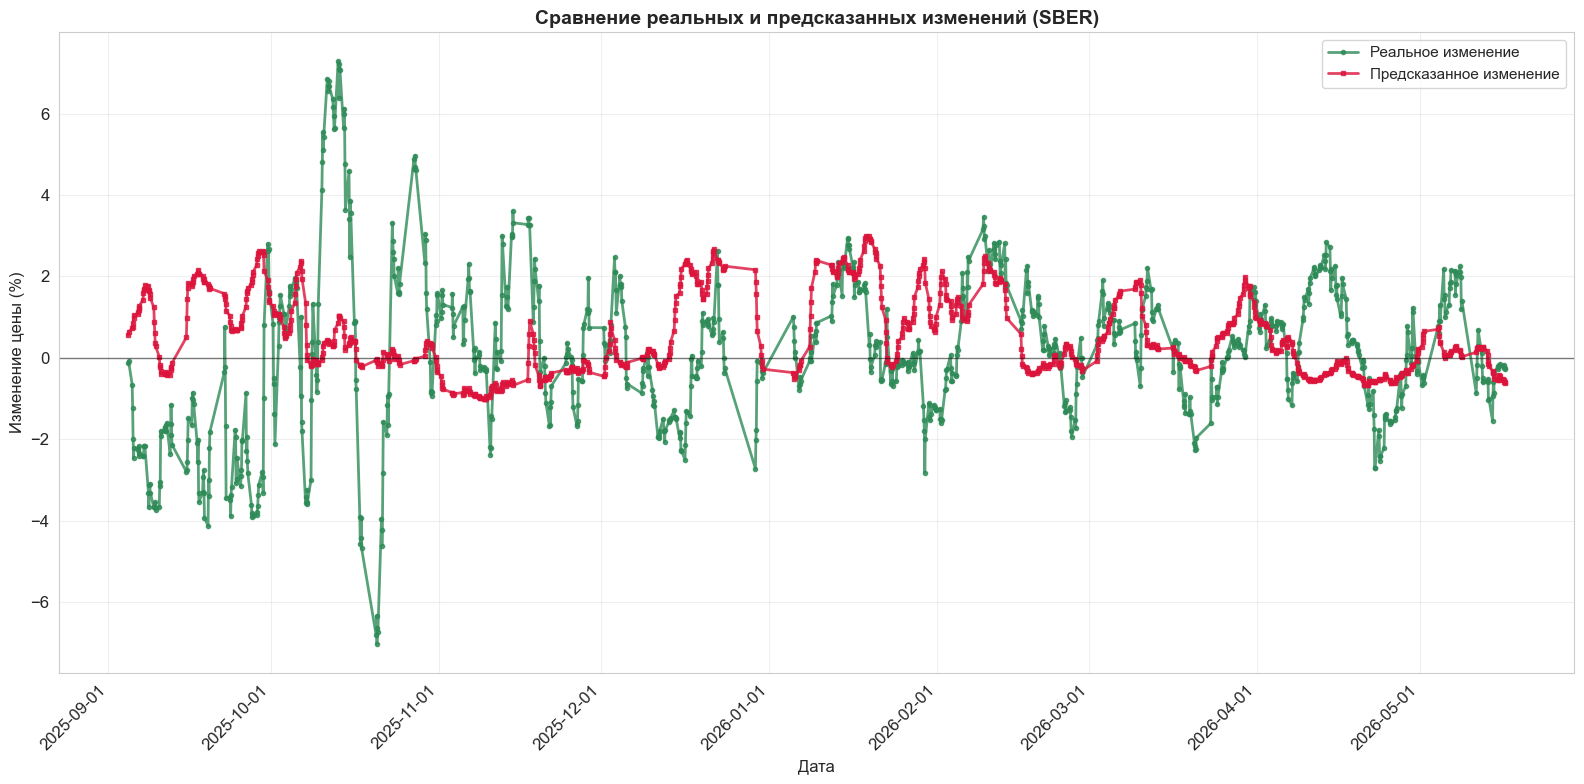

In [19]:
model.eval()
all_predictions = []
all_targets = []

with torch.no_grad():
    for features, targets, lengths in test_loader:
        features = features.to(device)
        predictions = model(features, lengths.to(device))
        all_predictions.extend(predictions.cpu().numpy().flatten())
        all_targets.extend(targets.numpy().flatten())

final_metrics = calculate_metrics(np.array(all_targets), np.array(all_predictions))

results_df = pd.DataFrame({
    'begin': features_by_ticker['SBER'].iloc[-len(all_predictions):]['begin'].values,
    'target_price_change': all_targets,
    'predict': all_predictions
})

visualize_predictions_comparison(
    results_df, 
    title="Сравнение реальных и предсказанных изменений (SBER)"
)

checkpoint = {
    'model_state_dict': model.state_dict(),
    'input_size': train_dataset.num_features,
    'hidden_size': HIDDEN_SIZE,
    'num_layers': NUM_LAYERS,
    'dropout': DROPOUT,
    'sequence_length': SEQUENCE_LENGTH,
    'feature_names': train_dataset.feature_names,
    'X_mean': train_dataset.X_mean,
    'X_std': train_dataset.X_std,
    'metrics': final_metrics
}

torch.save(checkpoint, 'lstm_stock_regressor_SBER.pt')

# Запуск экспериментов MlFlow

In [24]:
from copy import deepcopy
from itertools import product
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import json
import tempfile

SEED = 42
TICKER = 'SBER'
TARGET_COLUMN = 'target_price_change'
EXPERIMENT_NAME = 'sber_lstm_checkpoint'
TEST_SIZE = 0.2
VAL_SIZE = 0.2
FINAL_VAL_SIZE = 0.15
BASE_EPOCHS = 8
FINAL_EPOCHS = 12
BATCH_SIZE = 8
WEIGHT_DECAY = 0.01
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

mlflow.set_experiment(EXPERIMENT_NAME)

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def split_train_test(df, target_column, test_size=0.2, val_size=0.2):
    df = df.sort_values('begin').reset_index(drop=True)
    test_idx = int(len(df) * (1 - test_size))
    train_val_df = df.iloc[:test_idx].copy()
    test_df = df.iloc[test_idx:].copy()
    val_idx = int(len(train_val_df) * (1 - val_size))
    train_df = train_val_df.iloc[:val_idx].copy()
    val_df = train_val_df.iloc[val_idx:].copy()
    return train_df, val_df, test_df

def split_train_val(df, target_column, val_size=0.15):
    df = df.sort_values('begin').reset_index(drop=True)
    val_idx = int(len(df) * (1 - val_size))
    train_df = df.iloc[:val_idx].copy()
    val_df = df.iloc[val_idx:].copy()
    return train_df, val_df

class TemporalStockDataset(Dataset):
    def __init__(self, X, y, sequence_length, mean=None, std=None):
        if len(X) < sequence_length:
            raise ValueError('Not enough rows for the selected sequence_length')
        self.sequence_length = sequence_length
        self.feature_names = X.columns.tolist()
        self.num_features = len(self.feature_names)
        self.X_mean = np.asarray(X.mean().values if mean is None else mean)
        self.X_std = np.asarray(X.std().values if std is None else std)
        self.X_std[self.X_std == 0] = 1
        X_normalized = (X.values - self.X_mean) / self.X_std
        y_values = y.values
        self.sequences = []
        self.targets = []
        for i in range(len(X) - sequence_length + 1):
            self.sequences.append(X_normalized[i:i + sequence_length])
            self.targets.append(y_values[i + sequence_length - 1])
        self.sequences = np.asarray(self.sequences, dtype=np.float32)
        self.targets = np.asarray(self.targets, dtype=np.float32)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        features = torch.tensor(self.sequences[idx], dtype=torch.float32)
        target = torch.tensor(self.targets[idx], dtype=torch.float32)
        length = self.sequence_length
        return features, target, length

def make_loaders(train_df, val_df, test_df, sequence_length, batch_size):
    train_X = train_df.drop(columns=['begin', TARGET_COLUMN])
    train_y = train_df[TARGET_COLUMN]
    val_X = val_df.drop(columns=['begin', TARGET_COLUMN])
    val_y = val_df[TARGET_COLUMN]
    test_X = test_df.drop(columns=['begin', TARGET_COLUMN])
    test_y = test_df[TARGET_COLUMN]
    train_dataset = TemporalStockDataset(train_X, train_y, sequence_length)
    val_dataset = TemporalStockDataset(val_X, val_y, sequence_length, mean=train_dataset.X_mean, std=train_dataset.X_std)
    test_dataset = TemporalStockDataset(test_X, test_y, sequence_length, mean=train_dataset.X_mean, std=train_dataset.X_std)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader

def build_model(input_size, cfg):
    return StockLSTMRegressor(
        input_size=input_size,
        hidden_size=cfg['hidden_size'],
        num_layers=cfg['num_layers'],
        dropout=cfg['dropout'],
    ).to(DEVICE)

@torch.no_grad()
def evaluate_model(model, loader):
    device = next(model.parameters()).device
    all_predictions = []
    all_targets = []
    model.eval()
    for features, targets, lengths in loader:
        features = features.to(device)
        targets = targets.to(device).float().view(-1, 1)
        lengths = lengths.to(device)
        predictions = model(features, lengths)
        all_predictions.extend(predictions.cpu().numpy().reshape(-1))
        all_targets.extend(targets.cpu().numpy().reshape(-1))
    all_predictions = np.asarray(all_predictions).reshape(-1)
    all_targets = np.asarray(all_targets).reshape(-1)
    metrics = calculate_metrics(all_targets, all_predictions)
    return metrics, all_targets, all_predictions

def save_learning_curves(train_losses, val_losses, val_metrics, path):
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    axs[0, 0].plot(range(1, len(train_losses) + 1), train_losses, label='train', linewidth=2)
    axs[0, 0].plot(range(1, len(val_losses) + 1), val_losses, label='val', linewidth=2)
    axs[0, 0].set_ylabel('MSE Loss')
    axs[0, 0].set_xlabel('Epoch')
    axs[0, 0].set_title('Training and Validation Loss')
    axs[0, 0].legend()
    axs[0, 0].grid(True, alpha=0.3)
    axs[0, 1].plot(range(1, len(val_metrics['mae']) + 1), val_metrics['mae'], color='orange', linewidth=2)
    axs[0, 1].set_ylabel('MAE (%)')
    axs[0, 1].set_xlabel('Epoch')
    axs[0, 1].set_title('Mean Absolute Error')
    axs[0, 1].grid(True, alpha=0.3)
    axs[1, 0].plot(range(1, len(val_metrics['rmse']) + 1), val_metrics['rmse'], color='green', linewidth=2)
    axs[1, 0].set_ylabel('RMSE (%)')
    axs[1, 0].set_xlabel('Epoch')
    axs[1, 0].set_title('Root Mean Square Error')
    axs[1, 0].grid(True, alpha=0.3)
    axs[1, 1].plot(range(1, len(val_metrics['r2']) + 1), val_metrics['r2'], label='R²', color='purple', linewidth=2)
    axs[1, 1].plot(range(1, len(val_metrics['direction_accuracy']) + 1), val_metrics['direction_accuracy'], label='Direction Accuracy', color='red', linewidth=2)
    axs[1, 1].set_ylabel('Score')
    axs[1, 1].set_xlabel('Epoch')
    axs[1, 1].set_title('R² and Direction Accuracy')
    axs[1, 1].legend()
    axs[1, 1].grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)

def save_prediction_plot(results_df, path, title):
    df = results_df.copy()
    if df['begin'].dtype == 'object':
        df['begin'] = pd.to_datetime(df['begin'])
    df = df.sort_values('begin')
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.plot(df['begin'], df['target_price_change'], linewidth=2, color='#2E8B57', label='Реальное изменение', marker='o', markersize=3, alpha=0.8)
    ax.plot(df['begin'], df['predict'], linewidth=2, color='#DC143C', label='Предсказанное изменение', marker='s', markersize=3, alpha=0.8)
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Изменение цены (%)', fontsize=12)
    ax.set_xlabel('Дата', fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)

def run_experiment(cfg, train_df, val_df, test_df, stage='search', log_model=False):
    set_seed(cfg.get('seed', SEED))
    train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader = make_loaders(
        train_df, val_df, test_df, cfg['sequence_length'], cfg['batch_size']
    )
    model = build_model(train_dataset.num_features, cfg)
    optimizer = optim.Adam(model.parameters(), lr=cfg['learning_rate'], weight_decay=cfg['weight_decay'])
    scheduler = None
    with tempfile.TemporaryDirectory() as tmpdir, mlflow.start_run(run_name=cfg['run_name']) as run:
        tmpdir = Path(tmpdir)
        mlflow.set_tags({
            'ticker': cfg['ticker'],
            'stage': stage,
            'model_family': 'LSTM',
            'target': TARGET_COLUMN,
            'seed': str(cfg['seed']),
        })
        mlflow.log_dict(cfg, 'config.json')
        train_losses, val_losses, val_history = train(
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            train_loader=train_loader,
            val_loader=val_loader,
            num_epochs=cfg['num_epochs'],
        )
        train_metrics, _, _ = evaluate_model(model, train_loader)
        val_metrics, val_targets, val_preds = evaluate_model(model, val_loader)
        test_metrics, test_targets, test_preds = evaluate_model(model, test_loader)
        history_df = pd.DataFrame({
            'epoch': np.arange(1, len(train_losses) + 1),
            'train_loss': train_losses,
            'val_loss': val_losses,
            'val_mae': val_history['mae'],
            'val_rmse': val_history['rmse'],
            'val_r2': val_history['r2'],
            'val_direction_accuracy': val_history['direction_accuracy'],
        })
        history_df.to_csv(tmpdir / 'history.csv', index=False)
        save_learning_curves(train_losses, val_losses, val_history, tmpdir / 'learning_curves.png')
        test_dates = test_df.sort_values('begin').reset_index(drop=True).iloc[cfg['sequence_length'] - 1:]['begin'].reset_index(drop=True)
        predictions_df = pd.DataFrame({
            'begin': test_dates.iloc[:len(test_preds)].values,
            'target_price_change': test_targets[:len(test_preds)],
            'predict': test_preds[:len(test_preds)],
        })
        predictions_df.to_csv(tmpdir / 'test_predictions.csv', index=False)
        save_prediction_plot(predictions_df, tmpdir / 'predictions.png', f"{cfg['ticker']} predictions")
        summary = {
            'run_id': run.info.run_id,
            'run_name': cfg['run_name'],
            'ticker': cfg['ticker'],
            'sequence_length': cfg['sequence_length'],
            'hidden_size': cfg['hidden_size'],
            'num_layers': cfg['num_layers'],
            'dropout': cfg['dropout'],
            'learning_rate': cfg['learning_rate'],
            'batch_size': cfg['batch_size'],
            'num_epochs': cfg['num_epochs'],
            'seed': cfg['seed'],
            'train_mae': float(train_metrics['mae']),
            'train_rmse': float(train_metrics['rmse']),
            'train_r2': float(train_metrics['r2']),
            'train_direction_accuracy': float(train_metrics['direction_accuracy']),
            'val_mae': float(val_metrics['mae']),
            'val_rmse': float(val_metrics['rmse']),
            'val_r2': float(val_metrics['r2']),
            'val_direction_accuracy': float(val_metrics['direction_accuracy']),
            'test_mae': float(test_metrics['mae']),
            'test_rmse': float(test_metrics['rmse']),
            'test_r2': float(test_metrics['r2']),
            'test_direction_accuracy': float(test_metrics['direction_accuracy']),
            'config_json': json.dumps(cfg, ensure_ascii=False),
        }
        mlflow.log_metrics({k: v for k, v in summary.items() if isinstance(v, (int, float, np.floating)) and k not in {'seed'}})
        mlflow.log_artifacts(str(tmpdir))
        if log_model:
            checkpoint = {
                'model_state_dict': deepcopy(model).cpu().state_dict(),
                'input_size': train_dataset.num_features,
                'hidden_size': cfg['hidden_size'],
                'num_layers': cfg['num_layers'],
                'dropout': cfg['dropout'],
                'sequence_length': cfg['sequence_length'],
                'feature_names': train_dataset.feature_names,
                'X_mean': train_dataset.X_mean,
                'X_std': train_dataset.X_std,
                'summary': summary,
            }
            torch.save(checkpoint, tmpdir / 'checkpoint.pt')
            mlflow.pytorch.log_model(deepcopy(model).cpu(), 'model')
            mlflow.log_artifact(str(tmpdir / 'checkpoint.pt'))
        return summary, run.info.run_id

configs = []
depth_grid_main = list(product([5, 7, 9, 12, 16], [8, 16, 32, 64], [1, 2]))
depth_grid_deep = list(product([7, 9], [16, 32, 64, 96, 128], [3]))
full_grid = depth_grid_main + depth_grid_deep
for idx, (sequence_length, hidden_size, num_layers) in enumerate(full_grid, start=1):
    if num_layers == 1:
        dropout = 0.10 if hidden_size <= 32 else 0.15
        learning_rate = 6e-4 if hidden_size <= 32 else 4e-4
    elif num_layers == 2:
        dropout = 0.25 if hidden_size <= 32 else 0.30
        learning_rate = 4e-4 if hidden_size <= 32 else 3e-4
    else:
        dropout = 0.35 if hidden_size <= 64 else 0.40
        learning_rate = 3e-4 if hidden_size <= 64 else 2e-4
    configs.append({
        'run_name': f'sber_exp_{idx:02d}',
        'ticker': TICKER,
        'seed': SEED,
        'sequence_length': sequence_length,
        'hidden_size': hidden_size,
        'num_layers': num_layers,
        'dropout': dropout,
        'learning_rate': learning_rate,
        'batch_size': BATCH_SIZE,
        'weight_decay': WEIGHT_DECAY,
        'num_epochs': BASE_EPOCHS,
    })
len(configs)

50

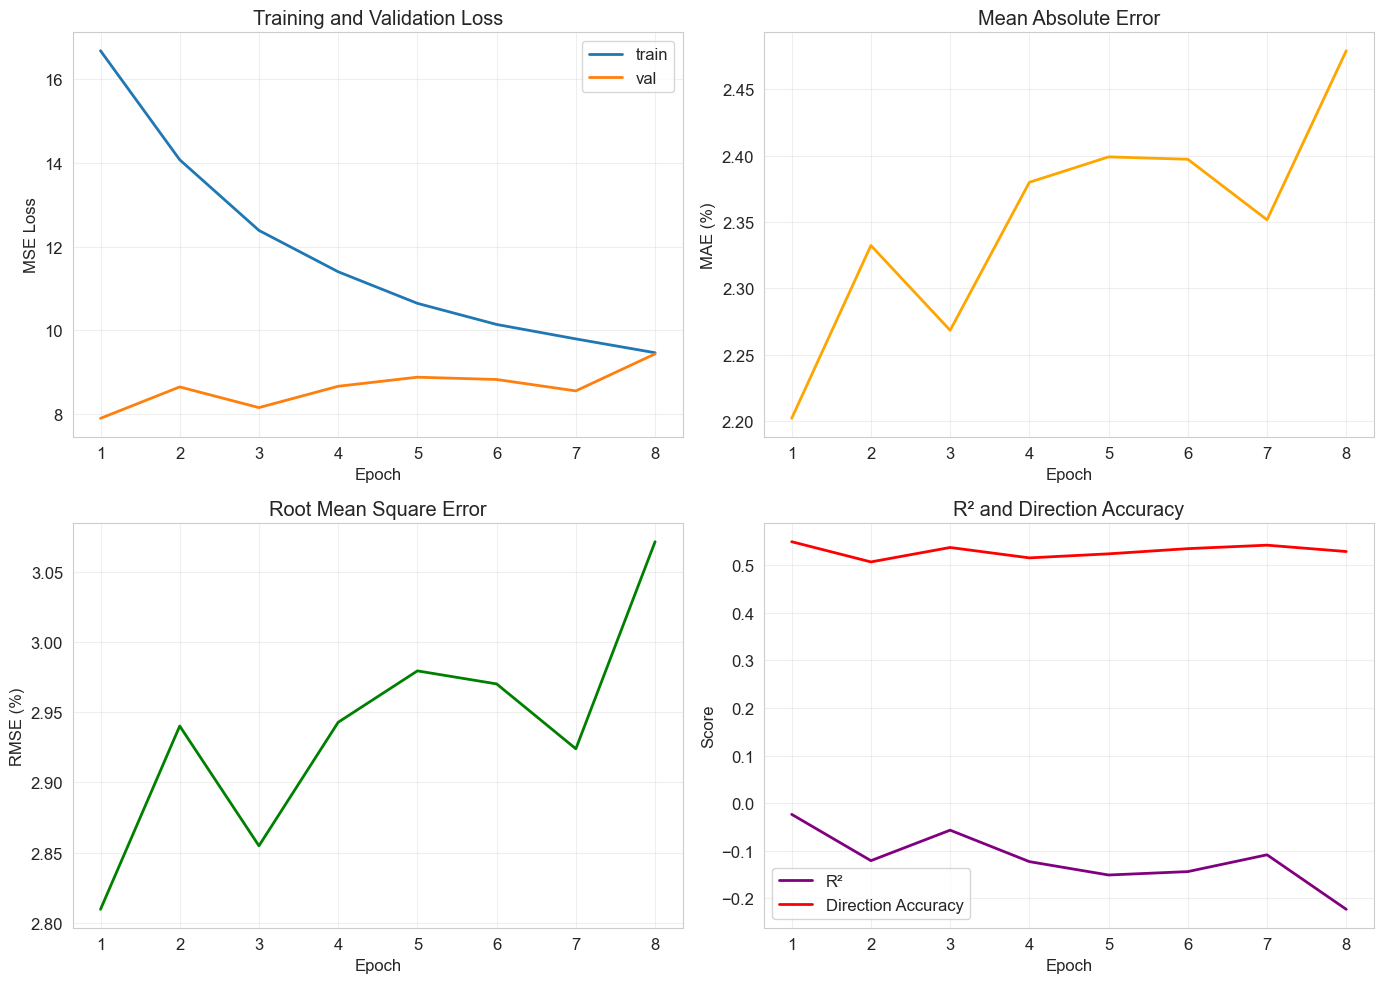


Epoch 8/8:
  Train Loss: 9.461260
  Val Loss:   9.433724
  MAE:  2.4789%
  RMSE: 3.0714%
  R²:   -0.2233
  Dir Acc: 0.5291
🏃 View run sber_exp_50 at: http://localhost:5050/#/experiments/3/runs/35632ddcfc1e40faa1af8db5c53f0242
🧪 View experiment at: http://localhost:5050/#/experiments/3


,run_id,run_name,ticker,sequence_length,hidden_size,num_layers,dropout,learning_rate,batch_size,num_epochs,...,train_direction_accuracy,val_mae,val_rmse,val_r2,val_direction_accuracy,test_mae,test_rmse,test_r2,test_direction_accuracy,config_json
0,d3dcc2781a7e437cb77a052949f4d92f,sber_exp_46,SBER,9,16,3,0.35,0.0003,8,8,...,0.793852,2.216015,2.753787,0.016622,0.538835,1.538777,2.066432,-0.139103,0.571705,"{""run_name"": ""sber_exp_46"", ""ticker"": ""SBER"", ..."
1,924248ccc0f5494388070288e849b611,sber_exp_02,SBER,5,8,2,0.25,0.0004,8,8,...,0.778447,2.209465,2.761951,0.007086,0.532609,1.888956,2.383215,-0.520135,0.501931,"{""run_name"": ""sber_exp_02"", ""ticker"": ""SBER"", ..."
2,ff0564876946417687e92f46014df099,sber_exp_10,SBER,7,8,2,0.25,0.0004,8,8,...,0.791867,2.222049,2.802671,-0.020700,0.548426,1.861093,2.308922,-0.424208,0.538685,"{""run_name"": ""sber_exp_10"", ""ticker"": ""SBER"", ..."
3,ff10a2a862b74a05b68a911dd463301a,sber_exp_41,SBER,7,16,3,0.35,0.0003,8,8,...,0.790964,2.256953,2.823089,-0.035625,0.552058,1.603125,2.174888,-0.263655,0.533849,"{""run_name"": ""sber_exp_41"", ""ticker"": ""SBER"", ..."
4,d9e28b9e303047cea94cd8ba0e80ea5b,sber_exp_48,SBER,9,64,3,0.35,0.0003,8,8,...,0.814949,2.242946,2.824592,-0.034597,0.563107,1.904079,2.423860,-0.567241,0.515504,"{""run_name"": ""sber_exp_48"", ""ticker"": ""SBER"", ..."
5,9e7e0444efab49a7b6512fb47d22761e,sber_exp_03,SBER,5,16,1,0.10,0.0006,8,8,...,0.769115,2.232298,2.831342,-0.043433,0.542271,1.789908,2.346798,-0.474032,0.509653,"{""run_name"": ""sber_exp_03"", ""ticker"": ""SBER"", ..."
6,83ef891f14474fad96390c6c3d14fdfb,sber_exp_18,SBER,9,8,2,0.25,0.0004,8,8,...,0.775769,2.237101,2.833862,-0.041399,0.540049,1.904286,2.344406,-0.466176,0.542636,"{""run_name"": ""sber_exp_18"", ""ticker"": ""SBER"", ..."
7,04edd167a2d941dc922ee6705fb12bc8,sber_exp_26,SBER,12,8,2,0.25,0.0004,8,8,...,0.790950,2.248429,2.836092,-0.040267,0.561510,2.061874,2.535475,-0.710262,0.552964,"{""run_name"": ""sber_exp_26"", ""ticker"": ""SBER"", ..."
8,030cb3f43beb47e0880b8312fc506820,sber_exp_33,SBER,16,8,1,0.10,0.0006,8,8,...,0.802175,2.270580,2.838891,-0.037961,0.581395,1.789484,2.287818,-0.393907,0.524878,"{""run_name"": ""sber_exp_33"", ""ticker"": ""SBER"", ..."
9,d85a971747a2470681ae56edf5045084,sber_exp_34,SBER,16,8,2,0.25,0.0004,8,8,...,0.801571,2.255884,2.868024,-0.059374,0.555692,1.846411,2.328116,-0.443445,0.573659,"{""run_name"": ""sber_exp_34"", ""ticker"": ""SBER"", ..."


In [ ]:
train_df, val_df, test_df = split_train_test(
    features_by_ticker[TICKER].copy(),
    target_column=TARGET_COLUMN,
    test_size=TEST_SIZE,
    val_size=VAL_SIZE,
 )

search_rows = []
for cfg in configs:
    run_summary, run_id = run_experiment(
        cfg=cfg,
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        stage='search',
        log_model=False,
    )
    search_rows.append(run_summary)

summary_df = pd.DataFrame(search_rows).sort_values(['val_direction_accuracy', 'val_r2', 'val_rmse'], ascending=[False, False, True]).reset_index(drop=True)
summary_df.to_csv('sber_search_summary.csv', index=False)
summary_df

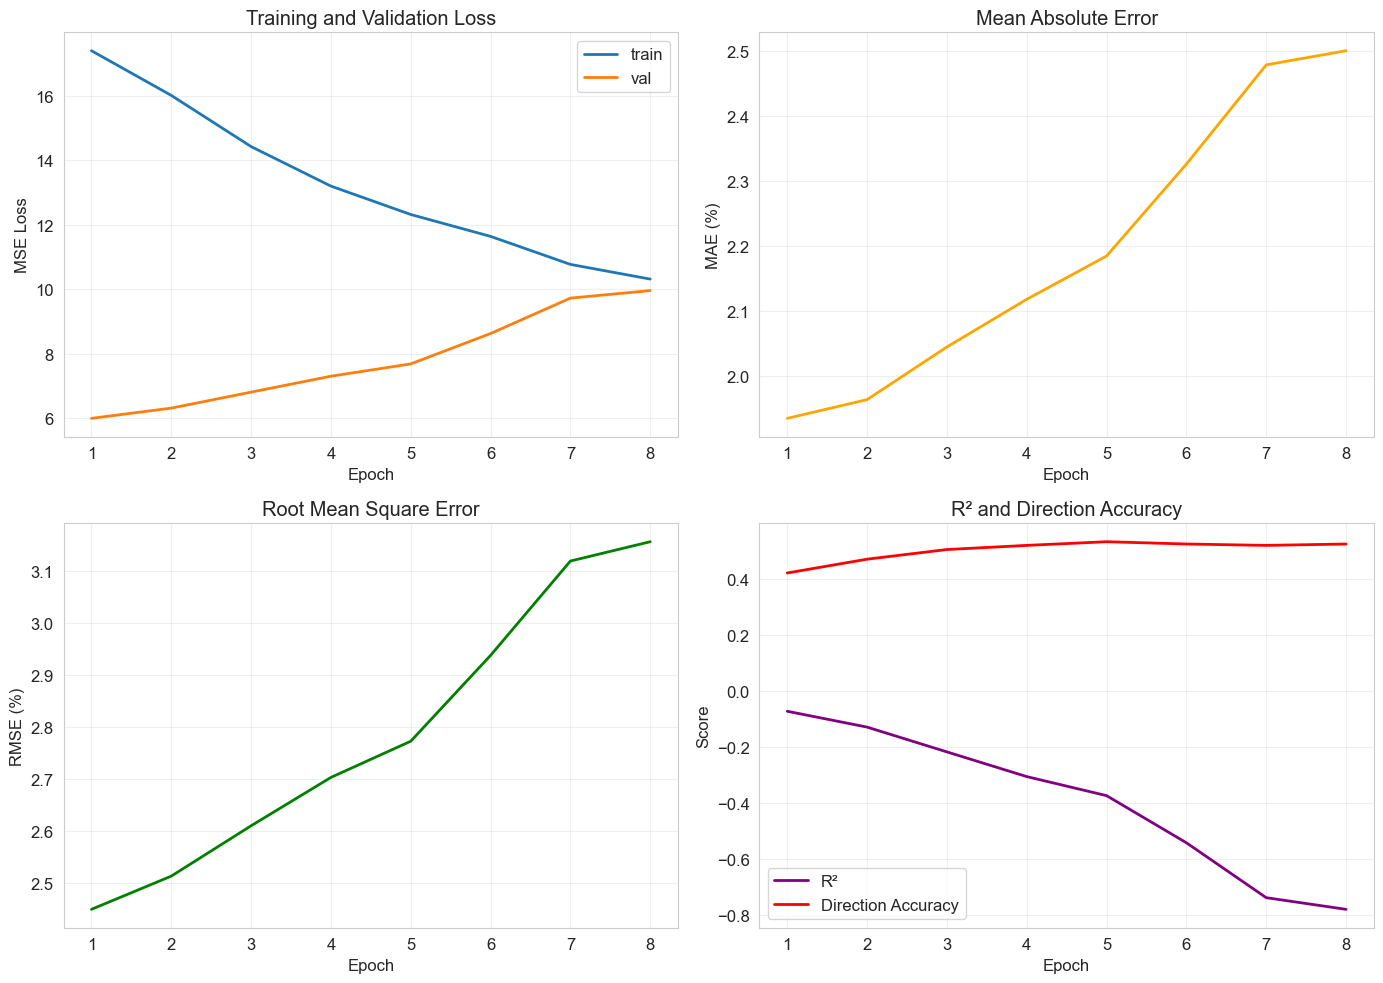


Epoch 8/8:
  Train Loss: 10.318297
  Val Loss:   9.962575
  MAE:  2.5005%
  RMSE: 3.1564%
  R²:   -0.7797
  Dir Acc: 0.5255


2026/06/01 11:03:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/01 11:03:48 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in C:\Users\baben_bakg1j1\HSE\annual_project\stocks-advisor
2026/06/01 11:03:50 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/01 11:03:50 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in C:\Users\baben_bakg1j1\HSE\annual_project\stocks-advisor
2026/06/01 11:03:50 INFO mlflow.utils.environment: Detected uv project at C:\Users\baben_bakg1j1\HSE\annual_project\stocks-advisor. Attempting to export requirements via 'uv export

🏃 View run sber_prd_sber_exp_33 at: http://localhost:5050/#/experiments/3/runs/e280eef90d4043109ae0a2a3cc7ded67
🧪 View experiment at: http://localhost:5050/#/experiments/3
e280eef90d4043109ae0a2a3cc7ded67
{'run_id': 'e280eef90d4043109ae0a2a3cc7ded67', 'run_name': 'sber_prd_sber_exp_33', 'ticker': 'SBER', 'sequence_length': 16, 'hidden_size': 8, 'num_layers': 1, 'dropout': 0.1, 'learning_rate': 0.0006, 'batch_size': 8, 'num_epochs': 8, 'seed': 42, 'train_mae': 2.0475893020629883, 'train_rmse': 3.098661422729492, 'train_r2': 0.4516717791557312, 'train_direction_accuracy': 0.8050582551861324, 'val_mae': 2.5004847049713135, 'val_rmse': 3.1563546657562256, 'val_r2': -0.7797353267669678, 'val_direction_accuracy': 0.5254515599343186, 'test_mae': 1.8306303024291992, 'test_rmse': 2.410179376602173, 'test_r2': -0.5469974279403687, 'test_direction_accuracy': 0.535609756097561, 'config_json': '{"run_name": "sber_prd_sber_exp_33", "ticker": "SBER", "seed": 42, "sequence_length": 16, "hidden_size": 

In [27]:
best_row = None
best_cfg = None
prd_run_summary = None

if 'summary_df' in globals() and not summary_df.empty:
    best_row = summary_df.sort_values(['val_direction_accuracy', 'val_r2', 'val_rmse'], ascending=[False, False, True]).iloc[0]
    best_cfg = json.loads(best_row['config_json'])
    prd_source_df = pd.concat([train_df, val_df]).sort_values('begin').reset_index(drop=True)
    prd_train_df, prd_val_df = split_train_val(prd_source_df, TARGET_COLUMN, val_size=FINAL_VAL_SIZE)
    prd_run_summary, prd_run_id = run_experiment(
        cfg={**best_cfg, 'num_epochs': best_cfg['num_epochs'], 'run_name': f"sber_prd_{best_row['run_name']}"},
        train_df=prd_train_df,
        val_df=prd_val_df,
        test_df=test_df,
        stage='prd',
        log_model=True,
    )
    prd_run_summary['best_search_run_id'] = best_row['run_id']
    prd_run_summary['best_search_val_direction_accuracy'] = float(best_row['val_direction_accuracy'])
    prd_run_summary['best_search_val_r2'] = float(best_row['val_r2'])
    prd_run_summary['best_search_val_rmse'] = float(best_row['val_rmse'])
    prd_run_summary['best_search_val_mae'] = float(best_row['val_mae'])
    print(prd_run_id)
    print(prd_run_summary)

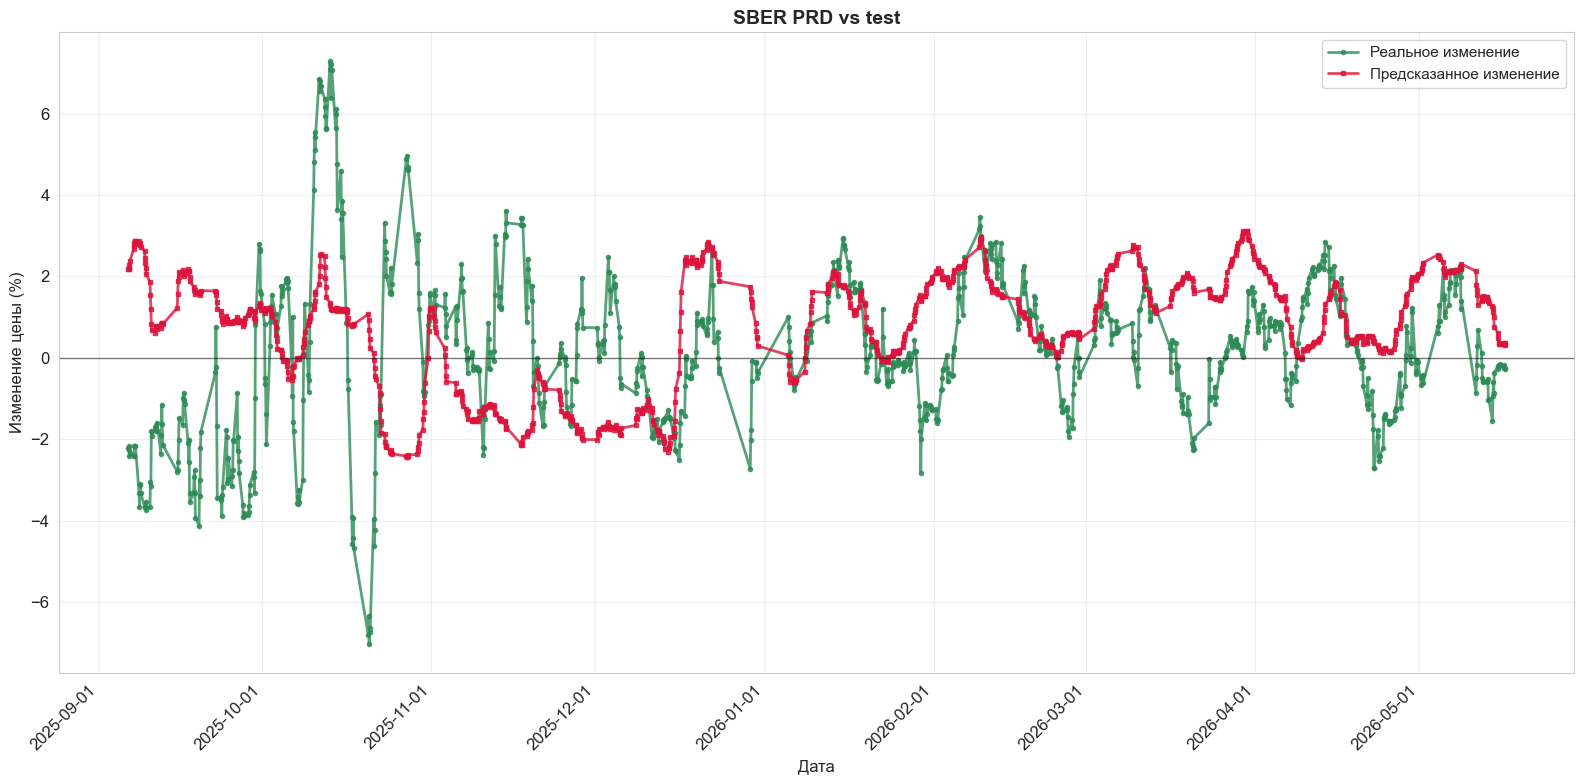

🏃 View run SBER_analysis at: http://localhost:5050/#/experiments/3/runs/35129a2993bd4334b8746b2a36a1220a
🧪 View experiment at: http://localhost:5050/#/experiments/3
   model_mae  model_rmse  model_r2  model_direction_accuracy  baseline_mae  \
0    1.83063    2.410179 -0.546997                   0.53561      1.450633   

   baseline_rmse  baseline_r2  baseline_direction_accuracy  
0       1.944206    -0.006643                     0.466341  
           model       mae      rmse        r2  direction_accuracy
0  zero_baseline  1.450633  1.944206 -0.006643            0.466341
             variant       mae      rmse        r2  direction_accuracy
0     zero_sentiment  1.912694  2.474225 -0.630306            0.520000
1  shifted_sentiment  1.834613  2.411794 -0.549071            0.534634
2    noise_sentiment  1.821488  2.400997 -0.535232            0.530732


,begin,target_price_change,predict,error,abs_error,direction_match
0,2025-10-20 10:00:00,-6.802454,1.070105,7.872559,7.872559,False
1,2025-10-20 14:00:00,-7.028283,0.683046,7.711329,7.711329,False
2,2025-10-27 14:00:00,4.968135,-2.447212,-7.415347,7.415347,False
3,2025-10-27 10:00:00,4.891782,-2.418660,-7.310442,7.310442,False
4,2025-10-20 12:00:00,-6.338330,0.926403,7.264733,7.264733,False
5,2025-10-27 16:00:00,4.696006,-2.402224,-7.098230,7.098230,False
6,2025-10-20 16:00:00,-6.637154,0.454800,7.091953,7.091953,False
7,2025-10-27 12:00:00,4.646337,-2.425055,-7.071392,7.071392,False
8,2025-10-27 18:00:00,4.623769,-2.390717,-7.014486,7.014486,False
9,2025-10-20 18:00:00,-6.738810,0.238752,6.977562,6.977562,False


In [29]:
if 'prd_run_id' not in globals():
    raise RuntimeError('PRD run is not available. Execute the search and PRD cells first.')

analysis_model = mlflow.pytorch.load_model(f'runs:/{prd_run_id}/model')
analysis_seq_len = int(prd_run_summary['sequence_length'])
analysis_batch_size = int(prd_run_summary['batch_size'])

_, _, _, _, _, analysis_test_loader = make_loaders(
    prd_train_df,
    prd_val_df,
    test_df,
    analysis_seq_len,
    analysis_batch_size,
 )

prd_test_metrics, y_true, y_pred = evaluate_model(analysis_model, analysis_test_loader)

test_dates = test_df.sort_values('begin').reset_index(drop=True).iloc[analysis_seq_len - 1:]['begin'].reset_index(drop=True)
predictions_df = pd.DataFrame({
    'begin': test_dates.iloc[:len(y_pred)].values,
    'target_price_change': y_true[:len(y_pred)],
    'predict': y_pred[:len(y_pred)],
})
predictions_df['error'] = predictions_df['predict'] - predictions_df['target_price_change']
predictions_df['abs_error'] = predictions_df['error'].abs()
predictions_df['direction_match'] = np.sign(predictions_df['predict']) == np.sign(predictions_df['target_price_change'])
visualize_predictions_comparison(predictions_df, title=f'{TICKER} PRD vs test')

baseline_preds = np.zeros_like(y_true)
baseline_metrics = calculate_metrics(y_true, baseline_preds)
baseline_df = pd.DataFrame([{
    'model': 'zero_baseline',
    'mae': float(baseline_metrics['mae']),
    'rmse': float(baseline_metrics['rmse']),
    'r2': float(baseline_metrics['r2']),
    'direction_accuracy': float(baseline_metrics['direction_accuracy']),
}])

top_errors_df = predictions_df.sort_values('abs_error', ascending=False).head(20).reset_index(drop=True)
error_summary_df = pd.DataFrame([{
    'model_mae': float(prd_test_metrics['mae']),
    'model_rmse': float(prd_test_metrics['rmse']),
    'model_r2': float(prd_test_metrics['r2']),
    'model_direction_accuracy': float(prd_test_metrics['direction_accuracy']),
    'baseline_mae': float(baseline_metrics['mae']),
    'baseline_rmse': float(baseline_metrics['rmse']),
    'baseline_r2': float(baseline_metrics['r2']),
    'baseline_direction_accuracy': float(baseline_metrics['direction_accuracy']),
}])

sentiment_cols = [col for col in test_df.columns if 'sentiment' in col]
robustness_rows = []
robust_variants = {
    'zero_sentiment': lambda frame: frame.assign(**{col: 0 for col in sentiment_cols}),
    'shifted_sentiment': lambda frame: frame.assign(**{col: frame[col].shift(1).fillna(0) for col in sentiment_cols}),
    'noise_sentiment': lambda frame: frame.assign(**{col: frame[col] + np.random.normal(0, 0.05, size=len(frame)) for col in sentiment_cols}),
}
for variant_name, transform in robust_variants.items():
    variant_test_df = transform(test_df.copy())
    _, _, _, _, _, variant_loader = make_loaders(prd_train_df, prd_val_df, variant_test_df, analysis_seq_len, analysis_batch_size)
    variant_metrics, _, _ = evaluate_model(analysis_model, variant_loader)
    robustness_rows.append({
        'variant': variant_name,
        'mae': float(variant_metrics['mae']),
        'rmse': float(variant_metrics['rmse']),
        'r2': float(variant_metrics['r2']),
        'direction_accuracy': float(variant_metrics['direction_accuracy']),
    })
robustness_df = pd.DataFrame(robustness_rows)

save_prediction_plot(predictions_df, 'prd_predictions.png', f'{TICKER} PRD predictions')
top_errors_df.to_csv('sber_top_errors.csv', index=False)
baseline_df.to_csv('sber_baseline.csv', index=False)
error_summary_df.to_csv('sber_error_summary.csv', index=False)
robustness_df.to_csv('sber_robustness.csv', index=False)

with tempfile.TemporaryDirectory() as tmpdir:
    tmpdir = Path(tmpdir)
    predictions_df.to_csv(tmpdir / 'prd_predictions.csv', index=False)
    top_errors_df.to_csv(tmpdir / 'sber_top_errors.csv', index=False)
    baseline_df.to_csv(tmpdir / 'sber_baseline.csv', index=False)
    error_summary_df.to_csv(tmpdir / 'sber_error_summary.csv', index=False)
    robustness_df.to_csv(tmpdir / 'sber_robustness.csv', index=False)
    save_prediction_plot(predictions_df, tmpdir / 'prd_predictions.png', f'{TICKER} PRD predictions')
    with mlflow.start_run(run_name=f'{TICKER}_analysis') as analysis_run:
        mlflow.set_tags({
            'ticker': TICKER,
            'stage': 'analysis',
            'source_prd_run_id': prd_run_id,
        })
        mlflow.log_metrics({
            'prd_mae': float(prd_test_metrics['mae']),
            'prd_rmse': float(prd_test_metrics['rmse']),
            'prd_r2': float(prd_test_metrics['r2']),
            'prd_direction_accuracy': float(prd_test_metrics['direction_accuracy']),
            'baseline_mae': float(baseline_metrics['mae']),
            'baseline_rmse': float(baseline_metrics['rmse']),
            'baseline_r2': float(baseline_metrics['r2']),
            'baseline_direction_accuracy': float(baseline_metrics['direction_accuracy']),
        })
        mlflow.log_artifacts(str(tmpdir))

print(error_summary_df)
print(baseline_df)
print(robustness_df)
top_errors_df

- Лучшая версия выбирается по `val_direction_accuracy`, затем по `val_r2`, затем по `val_rmse`.
- Дополнительное дообучение лучшего run не используется, потому что оно ухудшает качество на валидации.

## Эксперименты GAZP

Запуск 50 экспериментов для GAZP по той же схеме, что и для SBER.

In [ ]:
def build_ticker_configs(ticker_name):
    configs_local = []
    depth_grid_main_local = list(product([5, 7, 9, 12, 16], [8, 16, 32, 64], [1, 2]))
    depth_grid_deep_local = list(product([7, 9], [16, 32, 64, 96, 128], [3]))
    full_grid_local = depth_grid_main_local + depth_grid_deep_local
    for idx_local, (sequence_length, hidden_size, num_layers) in enumerate(full_grid_local, start=1):
        if num_layers == 1:
            dropout = 0.10 if hidden_size <= 32 else 0.15
            learning_rate = 6e-4 if hidden_size <= 32 else 4e-4
        elif num_layers == 2:
            dropout = 0.25 if hidden_size <= 32 else 0.30
            learning_rate = 4e-4 if hidden_size <= 32 else 3e-4
        else:
            dropout = 0.35 if hidden_size <= 64 else 0.40
            learning_rate = 3e-4 if hidden_size <= 64 else 2e-4
        configs_local.append({
            'run_name': f'{ticker_name.lower()}_exp_{idx_local:02d}',
            'ticker': ticker_name,
            'seed': SEED,
            'sequence_length': sequence_length,
            'hidden_size': hidden_size,
            'num_layers': num_layers,
            'dropout': dropout,
            'learning_rate': learning_rate,
            'batch_size': BATCH_SIZE,
            'weight_decay': WEIGHT_DECAY,
            'num_epochs': BASE_EPOCHS,
        })
    return configs_local

def run_ticker_experiments(ticker_name):
    ticker_df = features_by_ticker[ticker_name].copy()
    ticker_train_df, ticker_val_df, ticker_test_df = split_train_test(
        ticker_df,
        target_column=TARGET_COLUMN,
        test_size=TEST_SIZE,
        val_size=VAL_SIZE,
    )
    ticker_configs = build_ticker_configs(ticker_name)
    ticker_rows = []
    for cfg in ticker_configs:
        run_summary, run_id = run_experiment(
            cfg=cfg,
            train_df=ticker_train_df,
            val_df=ticker_val_df,
            test_df=ticker_test_df,
            stage='search',
            log_model=False,
        )
        ticker_rows.append(run_summary)
    ticker_summary_df = pd.DataFrame(ticker_rows).sort_values(['val_direction_accuracy', 'val_r2', 'val_rmse'], ascending=[False, False, True]).reset_index(drop=True)
    ticker_summary_df.to_csv(f'{ticker_name.lower()}_search_summary.csv', index=False)
    return ticker_summary_df

gazp_summary_df = run_ticker_experiments('GAZP')
gazp_summary_df

## Эксперименты LKOH

Запуск 50 экспериментов для LKOH по той же схеме, что и для SBER.

In [ ]:
lkoh_summary_df = run_ticker_experiments('LKOH')
lkoh_summary_df

## Эксперименты ROSN

Запуск 50 экспериментов для ROSN по той же схеме, что и для SBER.

In [ ]:
rosn_summary_df = run_ticker_experiments('ROSN')
rosn_summary_df

## Эксперименты TCSG

Запуск 50 экспериментов для TCSG по той же схеме, что и для SBER.

In [ ]:
tcsg_summary_df = run_ticker_experiments('TCSG')
tcsg_summary_df

## Пункты 1 и 2

- Для каждого тикера используется тот же helper `run_experiment`, что и для SBER: логируются гиперпараметры, train/val/test метрики, learning curves, prediction plots и конфиг эксперимента в MLflow.
- Лучший run выбирается по `val_direction_accuracy`, затем `val_r2`, затем `val_rmse`.
- Это оставляет одинаковую схему сравнения для всех тикеров и делает выбор финальной версии воспроизводимым.

In [ ]:
ticker_summaries = {
    'SBER': summary_df,
    'GAZP': gazp_summary_df,
    'LKOH': lkoh_summary_df,
    'ROSN': rosn_summary_df,
    'TCSG': tcsg_summary_df,
}

best_models_rows = []
for ticker_name, ticker_df in ticker_summaries.items():
    best_row_local = ticker_df.sort_values(['val_direction_accuracy', 'val_r2', 'val_rmse'], ascending=[False, False, True]).iloc[0]
    best_models_rows.append({
        'ticker': ticker_name,
        'run_name': best_row_local['run_name'],
        'run_id': best_row_local['run_id'],
        'sequence_length': best_row_local['sequence_length'],
        'hidden_size': best_row_local['hidden_size'],
        'num_layers': best_row_local['num_layers'],
        'dropout': best_row_local['dropout'],
        'learning_rate': best_row_local['learning_rate'],
        'val_mae': best_row_local['val_mae'],
        'val_rmse': best_row_local['val_rmse'],
        'val_r2': best_row_local['val_r2'],
        'val_direction_accuracy': best_row_local['val_direction_accuracy'],
        'test_mae': best_row_local['test_mae'],
        'test_rmse': best_row_local['test_rmse'],
        'test_r2': best_row_local['test_r2'],
        'test_direction_accuracy': best_row_local['test_direction_accuracy'],
    })

best_models_summary_df = pd.DataFrame(best_models_rows).sort_values('ticker').reset_index(drop=True)
best_models_summary_df.to_csv('best_models_summary.csv', index=False)
best_models_summary_df